In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
import warnings
import time
import sys
from sigma.toolkit import set_seed
from sigma.toolkit import clustering
from sigma.data.preparation import build_spatial_triplet_inputs, prepare_rna_atac_features
import matplotlib.pyplot as plt
set_seed(2024)
warnings.filterwarnings('ignore')
device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
print(device)
file_fold='../SIGMA_data/Mouse_Brain_H3K27me3/'
adata_omics1 = sc.read_h5ad(file_fold + 'adata_RNA.h5ad')
adata_omics3 = sc.read_h5ad(file_fold + 'adata_ATAC.h5ad')
adata_omics1.var_names_make_unique()
adata_omics3.var_names_make_unique()


/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda:7


In [2]:
adata_omics1, adata_omics3, adata_list = prepare_rna_atac_features(
    adata_rna=adata_omics1,
    adata_atac=adata_omics3,
    min_cells=10,
    n_top_genes=3000,
    rna_n_comps=30,
    atac_n_comps=50,
    align_atac=False,
    atac_scale_factor=1e4,
    atac_counts_per_cell_after=1e4,
)
x, edges, triplet_samples_list = build_spatial_triplet_inputs(
    adata_list=adata_list,
    rna_adata=adata_omics1,
    device=device,
    n_neighbors=4,
    edge_ratio=0.005,
    triplet_neighbors=3,
    farthest_ratio=0.4,
)


The graph contains 39008 edges, 9752 cells.
4.0000 neighbors per cell on average.
The graph contains 39008 edges, 9752 cells.
4.0000 neighbors per cell on average.
Original edges: 39008, planned new edges: 195
Actual directed new edges after deduplication: 370
  Final modality edge count: 39378
  Final modality edge count: 39378
Distances calculation completed!
The data using feature 'feat' contains 6978 mnn_anchors
Distances calculation completed!
The data using feature 'feat' contains 1712 mnn_anchors


In [3]:
from sigma.training import fit_sigma_embedding
t1 = time.time()
model = fit_sigma_embedding(
    adata=adata_omics1,
    features=x,
    edges=edges,
    triplet_samples_list=triplet_samples_list,
    weights=[1, 1, 1, 1],
    emb_dim=64,
    n_epochs=600,
    lr=0.007,
    weight_decay=1e-5,
    device=device,
    window_size=10,
    slope=0.0001,
    seed=2024,
)
t2 = time.time()
print(t2 - t1)


 46%|████▋     | 279/600 [00:30<00:34,  9.29it/s]


Early stopping at epoch 280: tri_slope=-0.000001, rec_slope=-0.000052
30.45014238357544


In [4]:
tool = 'mclust'  # mclust, leiden, and louvain
clustering(adata_omics1, key='SIGMA', add_key=f'SIGMA', n_clusters=12, method=tool, use_pca=True)
adata_omics1.obsm['spatial']=adata_omics1.obsm['spatial'][:,[1, 0]]


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


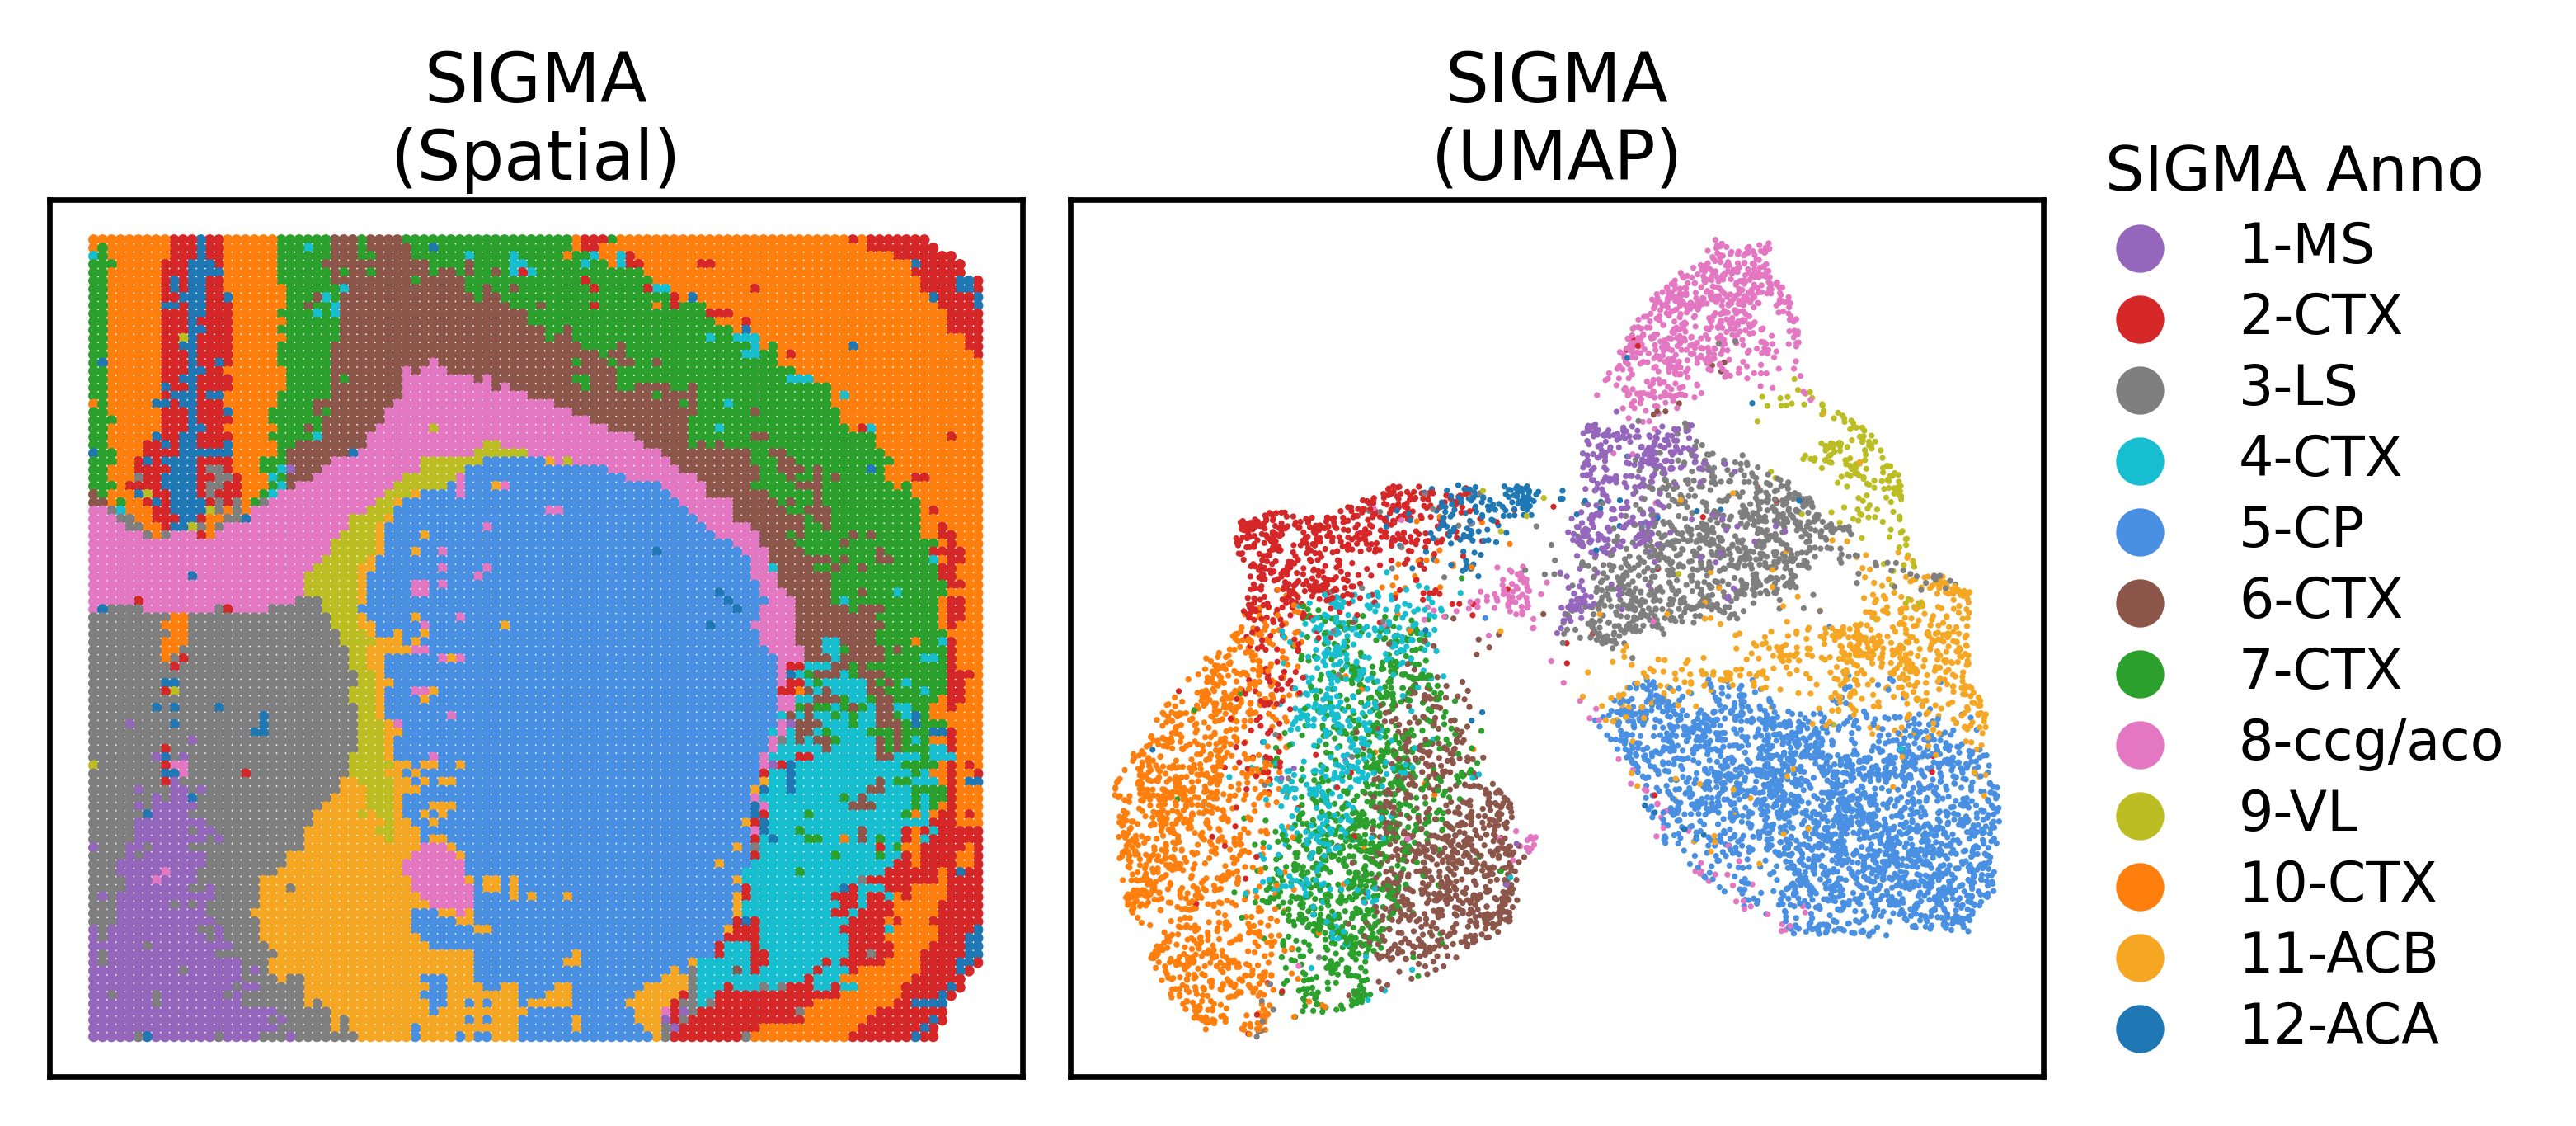

In [5]:
# ========== SIGMA method figure: one spatial panel + one UMAP panel ==========
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
from sigma.toolkit import clustering
plt.rcdefaults()
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["legend.fontsize"] = 8
plt.rcParams["legend.title_fontsize"] = 9
plt.rcParams["axes.titlepad"] = 3
plt.rcParams["legend.labelspacing"] = 0.3
# Use the corrected current SIGMA cluster id -> brain-region label map.
sigma_label_map = {
    1: "3-LS",
    2: "2-CTX",
    3: "5-CP",
    4: "7-CTX",
    5: "6-CTX",
    6: "1-MS",
    7: "8-ccg/aco",
    8: "12-ACA",
    9: "4-CTX",
    10: "9-VL",
    11: "11-ACB",
    12: "10-CTX",
}
sigma_plot_key = "SIGMA_12_anno_for_sigma"
sigma_anno_order = [
    "1-MS", "2-CTX", "3-LS", "4-CTX", "5-CP", "6-CTX",
    "7-CTX", "8-ccg/aco", "9-VL", "10-CTX", "11-ACB", "12-ACA",
]
sigma_palette = {
    "1-MS": "#9467bd",
    "2-CTX": "#d62728",
    "3-LS": "#7f7f7f",
    "4-CTX": "#17becf",
    "5-CP": "#4a90e2",
    "6-CTX": "#8c564b",
    "7-CTX": "#2ca02c",
    "8-ccg/aco": "#e377c2",
    "9-VL": "#bcbd22",
    "10-CTX": "#ff7f0e",
    "11-ACB": "#f5a623",
    "12-ACA": "#1f77b4",
}
if "SIGMA" not in adata_omics1.obs:
    clustering(adata_omics1, key="SIGMA", add_key="SIGMA", n_clusters=12, method="mclust", use_pca=True)
adata_omics1.obs[sigma_plot_key] = pd.Categorical(
    adata_omics1.obs["SIGMA"].astype(int).map(sigma_label_map),
    categories=sigma_anno_order,
    ordered=True,
)
if adata_omics1.obs[sigma_plot_key].isna().any():
    missing_ids = sorted(
        adata_omics1.obs.loc[adata_omics1.obs[sigma_plot_key].isna(), "SIGMA"].astype(str).unique(),
        key=lambda x: int(x) if x.isdigit() else x,
    )
    raise ValueError(f"sigma_label_map is missing SIGMA cluster ids: {missing_ids}")
# Use the current SIGMA/SIGMA embedding for UMAP.
if "SIGMA_best" in adata_omics1.obsm:
    current_rep = "SIGMA_best"
elif "SIGMA" in adata_omics1.obsm:
    current_rep = "SIGMA"
else:
    raise KeyError("Cannot find current method embedding in adata_omics1.obsm. Expected 'SIGMA_best' or 'SIGMA'.")
adata_sigma = adata_omics1.copy()
sc.pp.neighbors(adata_sigma, use_rep=current_rep, n_neighbors=10)
sc.tl.umap(adata_sigma, random_state=2024)
adata_sigma.uns.pop(f"{sigma_plot_key}_colors", None)
fig, ax_list = plt.subplots(1, 2, figsize=(5.2, 2.3), dpi=600)
plt.subplots_adjust(wspace=0.05)
sc.pl.embedding(
    adata_sigma,
    basis="spatial",
    color=sigma_plot_key,
    ax=ax_list[0],
    title="SIGMA\n(Spatial)",
    s=10,
    palette=sigma_palette,
    show=False,
)
sc.pl.umap(
    adata_sigma,
    color=sigma_plot_key,
    ax=ax_list[1],
    title="SIGMA\n(UMAP)",
    s=3,
    palette=sigma_palette,
    show=False,
)
for ax in ax_list:
    ax.set_xlabel("")
    ax.set_ylabel("")
if ax_list[0].get_legend() is not None:
    ax_list[0].get_legend().remove()
if ax_list[1].get_legend() is not None:
    ax_list[1].legend(loc=(1.02, 0), frameon=False, ncol=1, title="SIGMA Anno")
fig.savefig("SIGMA_method_spatial_umap.jpg", format="jpg", bbox_inches="tight", transparent=True)
fig.savefig("SIGMA_method_spatial_umap.png", format="png", bbox_inches="tight", transparent=True)
plt.show()


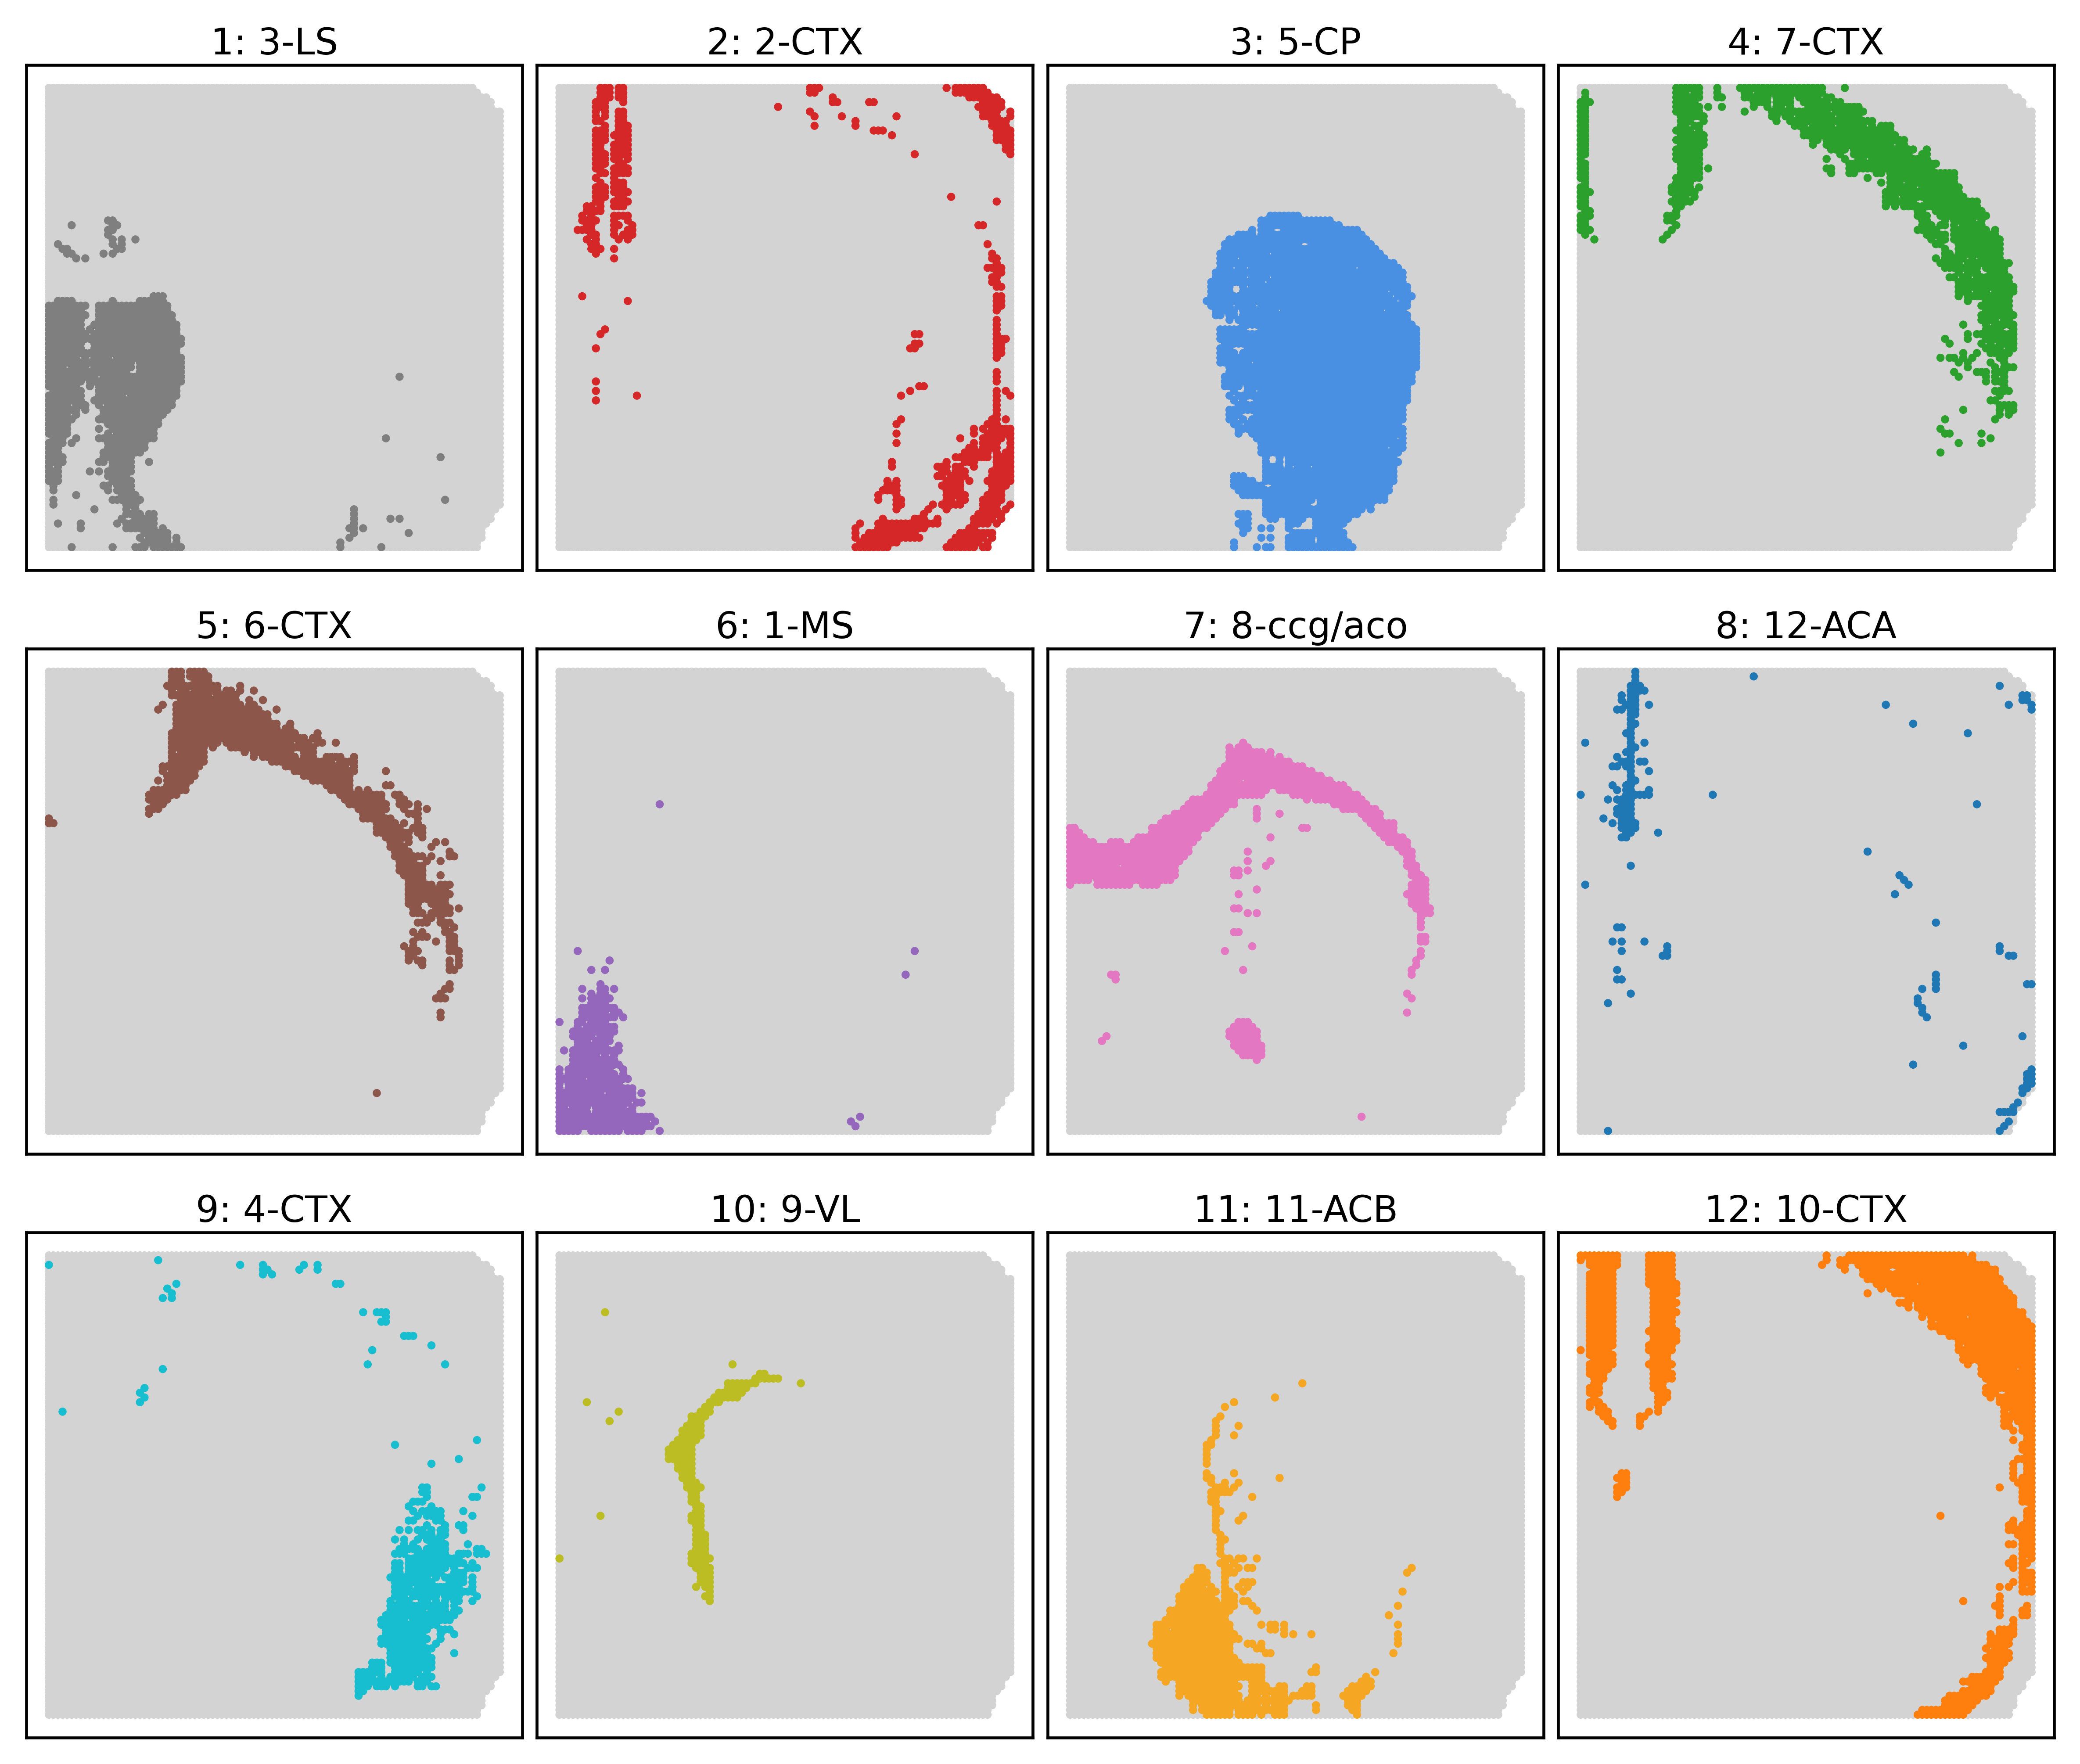

In [6]:
# ========== SIGMA spatial clusters: separate panels for each assigned brain region ==========
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
# Reuse sigma_label_map, sigma_anno_order, sigma_palette, and sigma_plot_key
# from the SIGMA method figure cell above. Run that cell first.
required_vars = ["sigma_label_map", "sigma_anno_order", "sigma_palette", "sigma_plot_key"]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Run the SIGMA method figure cell first. Missing variables: {missing_vars}")
adata_omics1.obs[sigma_plot_key] = pd.Categorical(
    adata_omics1.obs["SIGMA"].astype(int).map(sigma_label_map),
    categories=sigma_anno_order,
    ordered=True,
)
if adata_omics1.obs[sigma_plot_key].isna().any():
    missing_ids = sorted(
        adata_omics1.obs.loc[adata_omics1.obs[sigma_plot_key].isna(), "SIGMA"].astype(str).unique(),
        key=lambda x: int(x) if x.isdigit() else x,
    )
    raise ValueError(f"sigma_label_map is missing SIGMA cluster ids: {missing_ids}")
fig, ax_list = plt.subplots(3, 4, figsize=(8, 6.8), dpi=600)
for idx, (cluster_id, region_name) in enumerate(sigma_label_map.items()):
    row, col = divmod(idx, 4)
    ax = ax_list[row][col]
    label = f"{cluster_id}: {region_name}"
    sc.pl.embedding(
        adata_omics1,
        basis="spatial",
        color=sigma_plot_key,
        groups=[region_name],
        palette=sigma_palette,
        s=20,
        ax=ax,
        title=label,
        show=False,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        ax.get_legend().remove()
plt.tight_layout(w_pad=0.4)
fig.savefig("SIGMA_spatial_cluster_parts.jpg", format="jpg", bbox_inches="tight", transparent=True)
fig.savefig("SIGMA_spatial_cluster_parts.png", format="png", bbox_inches="tight", transparent=True)
plt.show()


fitting ...
  |======================================================================| 100%


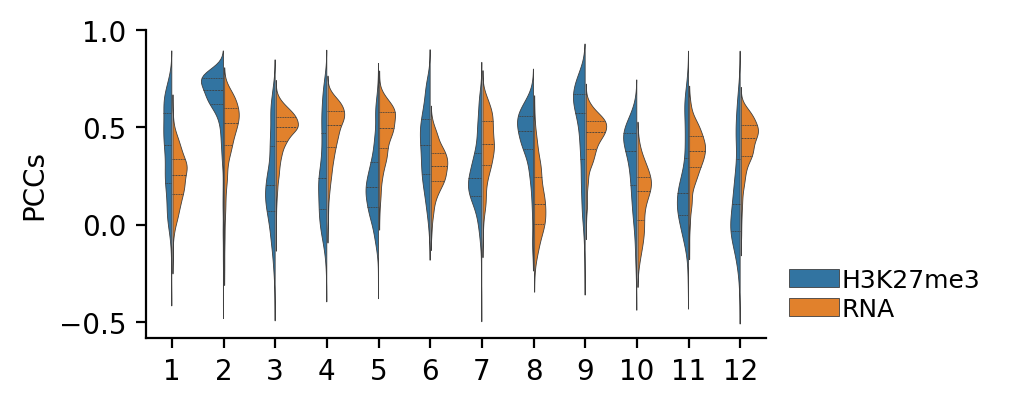

In [7]:
# ========== Current method PCCs by 12 clusters ==========
# Reproduce the reference PCCs2_12 figure: for the current method's 12 clusters, compute the Pearson correlation between embedding distance and H3K27me3/RNA distance.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from scipy.stats import pearsonr
from sigma.toolkit import clustering
# 1. Choose current method embedding.
# If hyperparameter search has already been run and SIGMA_best is available, use it first; otherwise use the current SIGMA embedding.
if "SIGMA_best" in adata_omics1.obsm:
    current_rep = "SIGMA_best"
elif "SIGMA" in adata_omics1.obsm:
    current_rep = "SIGMA"
else:
    raise KeyError("Cannot find current method embedding in adata_omics1.obsm. Expected 'SIGMA_best' or 'SIGMA'.")
# 2. Prepare modality embeddings for distance comparison.
# RNA uses adata_omics1.obsm['feat']; H3K27me3/ATAC uses adata_omics3.obsm['feat'].
if "feat" not in adata_omics1.obsm:
    raise KeyError("adata_omics1.obsm['feat'] not found. Run preprocessing first.")
if "feat" not in adata_omics3.obsm:
    raise KeyError("adata_omics3.obsm['feat'] not found. Run preprocessing first.")
# 3. Generate/use 12-cluster labels for current method.
cluster_key = "SIGMA_12_PCC"
if cluster_key not in adata_omics1.obs:
    clustering(
        adata_omics1,
        key=current_rep,
        add_key=cluster_key,
        n_clusters=12,
        method="mclust",
        use_pca=True,
    )
# 4. Compute per-spot Pearson correlations against modality distance profiles.
dis_atac = pairwise_distances(adata_omics3.obsm["feat"])
dis_rna = pairwise_distances(adata_omics1.obsm["feat"])
dis_current = pairwise_distances(adata_omics1.obsm[current_rep])
df2 = pd.DataFrame(columns=["cluster", "modality", "pearsonr"])
for idx, cluster_id in enumerate(adata_omics1.obs[cluster_key].values):
    corr, _ = pearsonr(dis_current[idx], dis_atac[idx])
    df2.loc[len(df2)] = [cluster_id, "H3K27me3", corr]
    corr, _ = pearsonr(dis_current[idx], dis_rna[idx])
    df2.loc[len(df2)] = [cluster_id, "RNA", corr]
df2["cluster"] = pd.Categorical(
    df2["cluster"],
    categories=sorted(pd.Series(adata_omics1.obs[cluster_key]).astype(int).unique()),
    ordered=True,
)
df2.to_csv("SIGMA_PCCs2_12_df.csv", index=False)
# 5. Plot, matching the reference style.
fig, ax = plt.subplots(figsize=(4, 2), dpi=200)
sns.violinplot(
    data=df2,
    x="cluster",
    y="pearsonr",
    hue="modality",
    split=True,
    gap=.05,
    inner="quart",
    linewidth=0.3,
    width=0.9,
    ax=ax,
)
ax.set_ylabel("PCCs")
ax.set_xlabel("")
ax.legend(bbox_to_anchor=(1, 0.3), frameon=False, ncol=1, labelspacing=0.2, handletextpad=0.1, fontsize=9)
sns.despine()
plt.show()
fig.savefig("SIGMA_PCCs2_12.svg", format="svg", bbox_inches="tight", transparent=True)
fig.savefig("SIGMA_PCCs2_12.jpg", format="jpg", bbox_inches="tight", transparent=True)
